In [ ]:
#archivo kaggle a google colab
from google.colab import files
files.upload() #elige kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tiznadoeth","key":"2d1da980274e052c5bf6bfb5e31166b6"}'}

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!ls ~/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

kaggle.json


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud -p /content/drive/MyDrive/temporal

creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import os
os.chdir("/content/drive/MyDrive/temporal")
!unzip -q creditcardfraud.zip

replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importamos los datos a un dataframe
df = pd.read_csv("/content/drive/MyDrive/temporal/creditcard.csv")

In [ ]:
#Visualizamos rapidamente nuestros datos
df
#Sabemos que time es el tiempo es segundos entre dicha transaccion y la transaccion inical de nuestros datos
# V1 es el resultado de reduccion de dimensionalidad PCA

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
#Sumamos el numero total de fraudes que tenemos en nuestros datos (Es la columna de Class donde 0 es no fraude y 1 es fraude)
#492
sum(df.Class)

492

In [ ]:
#Analizamos nuestros datos
df.shape
#(284807, 31)
df.info()
#Renglon 0 a 29 son float 64, renglon 30 es int64
df.isnull().sum()
#En nuestro caso no tenemos valores nulos en ninguno de nuestros renglones

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Text(0.5, 1.0, 'Correlaciones')

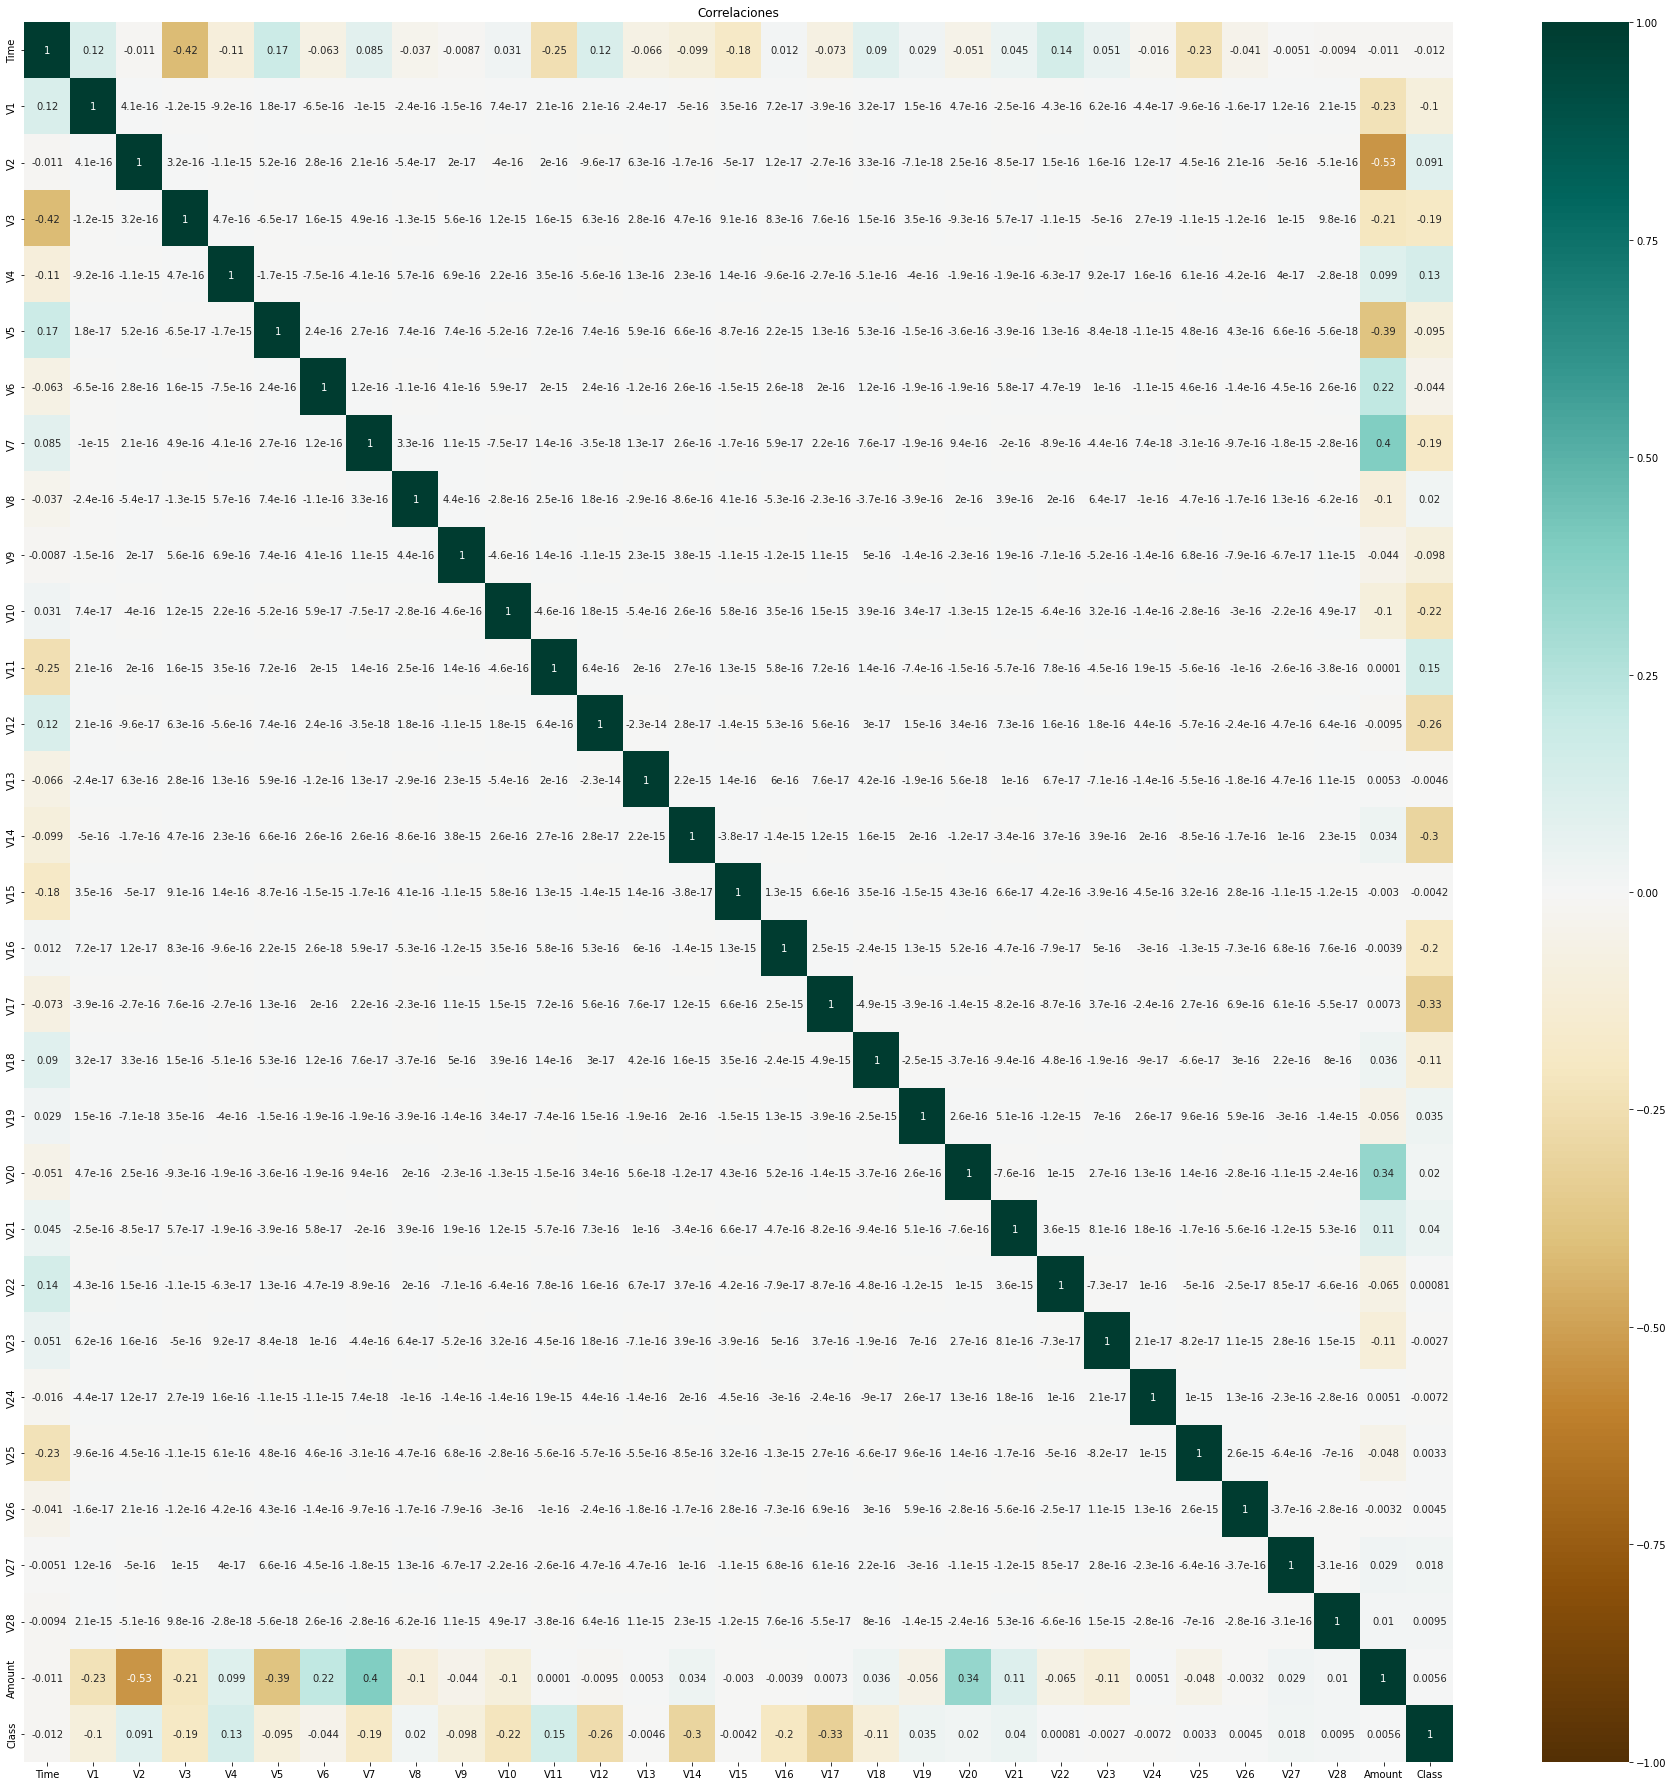

In [ ]:
#Encontramos el mapa de correlaciones de nuestro dataframe
plt.figure(figsize=(32,32))
heatmap = sns.heatmap(df.corr(),vmin=-1,vmax=1,annot=True,cmap='BrBG')
heatmap.set_title('Correlaciones')
#Donde no encontramos en realidad alguna correlacion  lo suficientemente fuerte para ser eliminada

In [ ]:
#Dividimos Nuestros datos en train, test.
#En el primer caso usamos el train como 80% de los datos y test como 20% de los datos
from sklearn.model_selection import train_test_split


# Separamos la variable que queremos analizar (Class como y) y eliminamos ese mismo dato de nuestro dataframe (X)
y = df['Class']
X = df.drop(['Class'],1)


#Separamos nuestros datos como y, X en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  


In [ ]:
#X_train,shape es (227845, 30)
X_train.shape
#X_test.shape es (56962, 30)
X_test.shape
#y_train.shape es (227845,1)
y_train.shape
#y_test.shape es (56962,1)
y_test.shape

(56962,)

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
tf.convert_to_tensor(X_train)
tf.convert_to_tensor(X_test)
tf.convert_to_tensor(y_train)
tf.convert_to_tensor(y_test)

<tf.Tensor: shape=(56962,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 0, 0])>

In [ ]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train)


In [ ]:
normalizer(X_train.iloc[:3])

<tf.Tensor: shape=(3, 30), dtype=float32, numpy=
array([[ 1.1530714e+00, -7.7114217e-02,  6.4217484e-01, -2.0667224e+00,
        -1.0165006e+00,  2.5070407e+00,  2.0137057e+00,  4.2822227e-01,
         8.4038943e-01, -6.5042382e-01, -9.4682479e-01, -1.0008317e-01,
        -1.7666131e-01, -5.2090192e-01, -3.1428108e-01, -3.7826514e-01,
        -2.0320208e-01,  9.8708844e-01, -1.7803581e-01, -5.3152424e-01,
        -3.2822710e-01,  2.9104823e-01,  6.6571134e-01, -1.8641515e-01,
         1.1030825e+00, -7.5608450e-01,  1.1395872e+00, -4.1516268e-01,
         1.2115907e-01, -3.3956325e-01],
       [ 4.8778427e-01, -1.7572716e-01,  5.4777467e-01,  3.6681277e-01,
        -1.3809401e-01,  8.3728924e-02, -3.8714731e-01,  6.5060717e-01,
        -4.6053669e-01, -1.6044040e+00,  6.2296170e-01,  3.9852250e-01,
        -7.8291351e-01,  1.0270685e+00, -1.7680691e+00,  1.2776610e+00,
        -3.8760889e-01,  2.7497494e+00, -1.2952830e+00,  4.1126719e+00,
         9.2578852e-01, -1.0564473e-01,  1.496

In [ ]:
def get_basic_model():
  model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(30, activation='relu'),

    tf.keras.layers.Dense(1)
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                metrics=['accuracy'])
  return model

In [ ]:
BATCH_SIZE = 100000
model = get_basic_model()
history = model.fit(X_train,y_train, epochs=50, batch_size=BATCH_SIZE,validation_data=(X_test, y_test))

Epoch 1/50
3/3 [==============================] - 2s 476ms/step - loss: 1.0637 - accuracy: 0.5111 - val_loss: 0.9789 - val_accuracy: 0.6107
Epoch 2/50
3/3 [==============================] - 0s 92ms/step - loss: 0.9565 - accuracy: 0.6388 - val_loss: 0.8796 - val_accuracy: 0.7289
Epoch 3/50
3/3 [==============================] - 0s 83ms/step - loss: 0.8595 - accuracy: 0.7512 - val_loss: 0.7904 - val_accuracy: 0.8256
Epoch 4/50
3/3 [==============================] - 0s 87ms/step - loss: 0.7725 - accuracy: 0.8441 - val_loss: 0.7112 - val_accuracy: 0.9038
Epoch 5/50
3/3 [==============================] - 0s 90ms/step - loss: 0.6953 - accuracy: 0.9158 - val_loss: 0.6412 - val_accuracy: 0.9506
Epoch 6/50
3/3 [==============================] - 0s 90ms/step - loss: 0.6273 - accuracy: 0.9574 - val_loss: 0.5796 - val_accuracy: 0.9764
Epoch 7/50
3/3 [==============================] - 0s 82ms/step - loss: 0.5674 - accuracy: 0.9805 - val_loss: 0.5254 - val_accuracy: 0.9900
Epoch 8/50
3/3 [==========

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


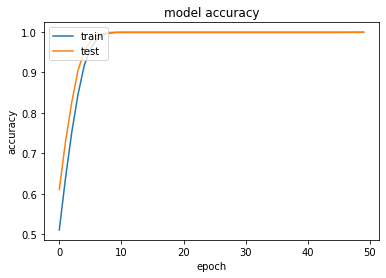

In [ ]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

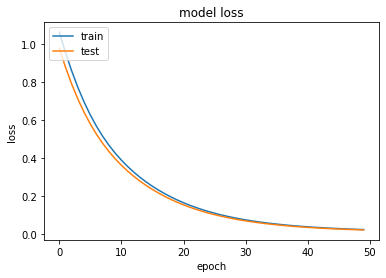

In [ ]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()